# 01 · Exploración de los datos

**Objetivo:** descargar los precios, limpiarlos y entender sus rendimientos antes de construir nada encima.

**Necesitas:** TODO 1.1, 1.2 y 1.3 de `src/data.py`. Checkpoint: `python -m pytest tests/test_data.py`.

**Teoría:** `docs/01_Datos_y_rendimientos.pdf`.

**Cómo usar este notebook.** Ejecuta las celdas en orden. Una celda que llama a una función que todavía es un TODO falla con `NotImplementedError: TODO x.y`: completa ese TODO, pasa su checkpoint de `pytest` y vuelve a ejecutarla (con `autoreload` no hace falta reiniciar el kernel).

Las celdas marcadas **`# TODO (análisis)`** son tuyas y no las corrige ningún test: sirven para mirar los datos y responder a las preguntas. Hasta que las completes no hacen nada (`...`).

In [1]:
# Configuración: localiza la raíz del repo y recarga src/ al guardar cambios (no hace falta reiniciar)
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src import backtest, config, data, metrics, plotting, strategies, walkforward

plotting.apply_style()
pd.set_option("display.width", 140)

## 1. Descarga

Si todavía no has descargado los datos, esta celda lo hace (equivale a `python -m src.data` en la terminal). Los precios se guardan *en bruto* en `data/raw/prices.parquet`; la limpieza se aplica al cargarlos.

In [2]:
if not config.PRICES_FILE.exists():
    data.main([])

meta = json.loads(config.PRICES_META_FILE.read_text(encoding="utf-8"))
{k: meta[k] for k in ("rows", "first_date", "last_date", "downloaded_at", "yfinance")}

{'rows': 4216,
 'first_date': '2010-01-04',
 'last_date': '2026-10-07',
 'downloaded_at': '2026-10-07T16:01:27+00:00',
 'yfinance': '1.7.0'}

## 2. Precios en bruto

Antes de limpiar, mira qué ha llegado: huecos, fechas, valores raros.

In [3]:
raw = data.load_prices(clean=False)
raw.tail()

,SPY,QQQ,IWM,EFA,GLD,TLT,AAPL,MSFT,JPM,XOM
Date,,,,,,,,,,
2026-10-01,763.989990,742.030029,279.019989,102.820000,382.760010,77.709999,330.320007,512.799988,331.526031,163.820007
2026-10-02,769.640015,749.580017,281.519989,103.959999,380.140015,77.480003,333.690002,517.530029,330.730011,164.009995
2026-10-05,774.830017,756.200012,283.380005,104.029999,379.549988,77.110001,332.890015,525.179993,330.730011,164.000000
2026-10-06,779.090027,759.659973,281.339996,104.220001,382.269989,77.279999,333.630005,529.299988,331.279999,164.479996
2026-10-07,776.446472,756.445007,277.760010,103.059998,376.505005,76.930000,334.769989,527.609985,328.000000,163.710007


In [4]:
print("Fechas ordenadas:", raw.index.is_monotonic_increasing, "| Fechas repetidas:", raw.index.has_duplicates)
print("Precios <= 0:", int((raw <= 0).sum().sum()))
raw.isna().sum().rename("NaN").to_frame().T

Fechas ordenadas: True | Fechas repetidas: False
Precios <= 0: 0


,SPY,QQQ,IWM,EFA,GLD,TLT,AAPL,MSFT,JPM,XOM
NaN,0,0,0,0,0,0,0,0,0,0


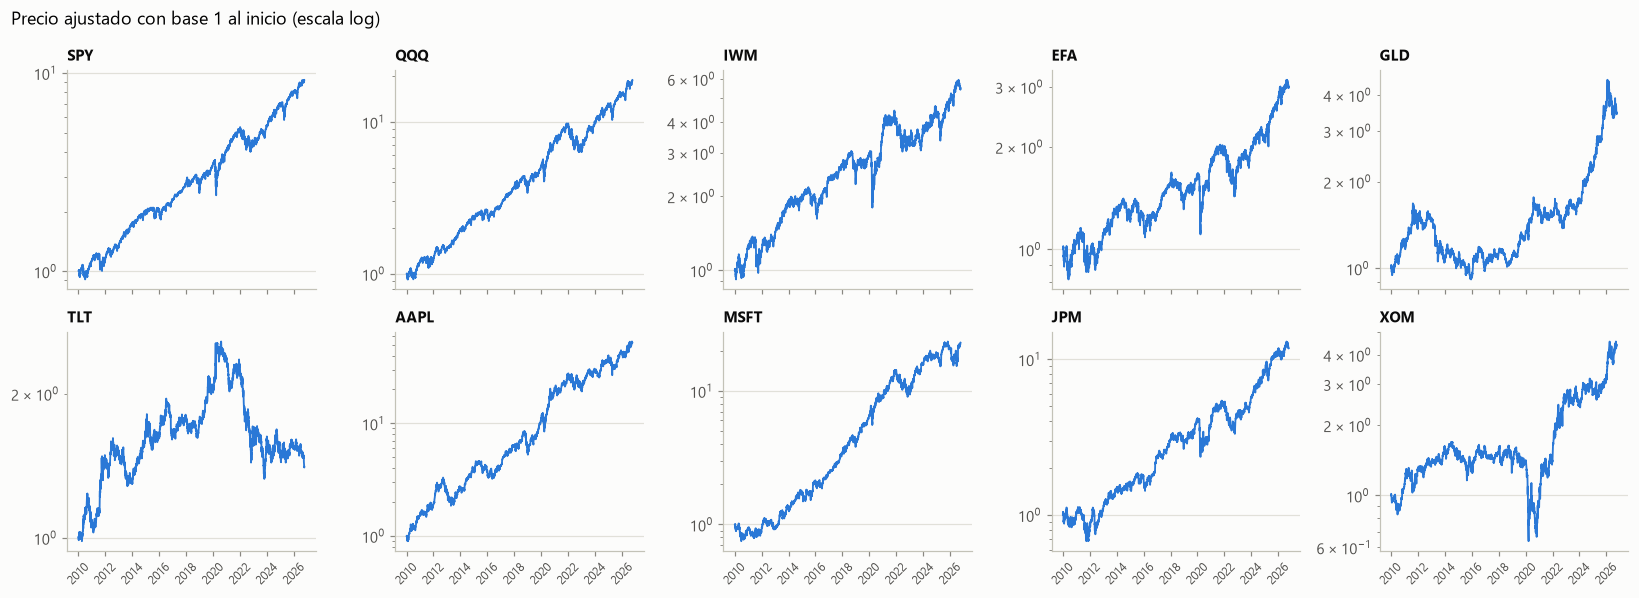

In [5]:
# Un gráfico por activo (10 series en un solo gráfico no se leen)
normalized = raw.apply(lambda s: s / s.dropna().iloc[0])
fig, axes = plt.subplots(2, 5, figsize=(15, 5.5), sharex=True)
for ax, ticker in zip(axes.flat, raw.columns):
    ax.plot(normalized.index, normalized[ticker], color=plotting.PALETTE[0], linewidth=1.2)
    ax.set_yscale("log")
    ax.set_title(ticker, fontsize=10)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
fig.suptitle("Precio ajustado con base 1 al inicio (escala log)", x=0.01, ha="left")
fig.tight_layout()

> **Pregunta.** Son precios *ajustados* (`auto_adjust=True`: dividendos y splits). AAPL hizo un split 4:1 el 31-08-2020: ¿ves algún salto ese día? ¿Qué pasaría en un backtest con precios sin ajustar? ¿Y si una acción paga un dividendo del 4 %?

## 3. Limpieza (TODO 1.3)

In [6]:
prices = data.clean_prices(raw)
print(f"{len(raw)} filas en bruto -> {len(prices)} limpias. NaN restantes: {int(prices.isna().sum().sum())}")
prices.head()

4216 filas en bruto -> 4216 limpias. NaN restantes: 0


,SPY,QQQ,IWM,EFA,GLD,TLT,AAPL,MSFT,JPM,XOM
Date,,,,,,,,,,
2010-01-04,84.368980,40.204659,51.111198,34.581203,109.800003,54.849892,6.400961,22.984243,28.012621,37.136806
2010-01-05,84.592300,40.204659,50.935448,34.611687,109.699997,55.204163,6.412027,22.991663,28.555220,37.281803
2010-01-06,84.651901,39.962162,50.887531,34.757980,111.510002,54.465145,6.310034,22.850567,28.712114,37.604034
2010-01-07,85.009186,39.988140,51.262985,34.623871,110.820000,54.556755,6.298369,22.612928,29.280876,37.485897
2010-01-08,85.292114,40.317253,51.542587,34.898186,111.370003,54.532341,6.340243,22.768871,29.208963,37.335518


Los datos de Yahoo de estos tickers vienen bastante limpios, así que comprueba la limpieza con una tabla sucia hecha a mano. Recorre los 5 pasos del docstring de `clean_prices` y verifica cada uno en la salida.

In [7]:
dirty = pd.DataFrame(
    {"A": [10.0, np.nan, -1.0, 11.0, 12.0, 12.5], "B": [np.nan, 5.0, 5.5, 5.4, 5.6, 5.7]},
    index=pd.to_datetime(["2024-01-03", "2024-01-01", "2024-01-02", "2024-01-04", "2024-01-04", "2024-01-05"]),
)
display(dirty)
data.clean_prices(dirty)

,A,B
2024-01-03,10.0,NaN
2024-01-01,NaN,5.0
2024-01-02,-1.0,5.5
2024-01-04,11.0,5.4
2024-01-04,12.0,5.6
2024-01-05,12.5,5.7


,A,B
2024-01-03,10.0,5.5
2024-01-04,12.0,5.6
2024-01-05,12.5,5.7


> **Preguntas.** ¿Por qué la fila del 2024-01-01 desaparece? ¿Qué valor queda el 2024-01-04 y por qué? ¿Por qué está prohibido el `bfill`?

## 4. Rendimientos (TODO 1.1 y 1.2)

In [8]:
rets = data.simple_returns(prices)
logrets = data.log_returns(prices)
rets.describe().T.style.format("{:.4f}")

,count,mean,std,min,25%,50%,75%,max
SPY,4215.0000,0.0006,0.0107,-0.1094,-0.0037,0.0007,0.0058,0.1050
QQQ,4215.0000,0.0008,0.0130,-0.1198,-0.0048,0.0012,0.0074,0.1200
IWM,4215.0000,0.0005,0.0139,-0.1327,-0.0067,0.0010,0.0081,0.0915
EFA,4215.0000,0.0003,0.0115,-0.1099,-0.0051,0.0006,0.0063,0.0847
GLD,4215.0000,0.0003,0.0106,-0.1027,-0.0049,0.0005,0.0058,0.0636
TLT,4215.0000,0.0001,0.0094,-0.0667,-0.0056,0.0005,0.0057,0.0752
AAPL,4215.0000,0.0011,0.0177,-0.1286,-0.0074,0.0010,0.0103,0.1533
MSFT,4215.0000,0.0009,0.0164,-0.1474,-0.0072,0.0007,0.0092,0.1551
JPM,4215.0000,0.0007,0.0172,-0.1496,-0.0075,0.0007,0.0091,0.1801
XOM,4215.0000,0.0005,0.0158,-0.1222,-0.0073,0.0003,0.0083,0.1269


In [12]:
# TODO (análisis): tabla por activo con
#   - rendimiento medio anualizado  (media diaria × 252)
#   - volatilidad anualizada        (desviación diaria × √252)
#   - su cociente (un "Sharpe" sin costes ni tipo libre)
# ordenada por el cociente de mayor a menor.
# Pista: pd.DataFrame({...}) con tres Series que comparten índice; sort_values(...).
r_medio = rets.mean() * config.TRADING_DAYS
volatilidad = rets.std() * np.sqrt(config.TRADING_DAYS)
by_asset = pd.DataFrame({
    "media anual": r_medio,
    "vol anual": volatilidad,
})
by_asset["Sharpe"] = by_asset["media anual"] / by_asset["vol anual"]
by_asset = by_asset.sort_values(by="Sharpe", ascending=False)
by_asset

,media anual,vol anual,Sharpe
AAPL,0.276120,0.280907,0.982961
QQQ,0.196830,0.206323,0.953992
SPY,0.147288,0.170414,0.864293
MSFT,0.221273,0.260516,0.849365
JPM,0.184564,0.273762,0.674178
IWM,0.125796,0.221258,0.568551
GLD,0.087827,0.167869,0.523188
XOM,0.120013,0.250161,0.479741
EFA,0.082145,0.183165,0.448478
TLT,0.031312,0.148935,0.210243


In [25]:
# TODO (análisis): rendimientos simples frente a logarítmicos en el SPY.
#   1) ¿Cuál es la diferencia media y la máxima entre ambos?
#   2) ¿Qué día difieren más? (pista: idxmax). ¿Qué pasó ese día?
spy_rets = rets["SPY"]
spy_logrets = logrets["SPY"]
mean_diff = np.mean(spy_rets - spy_logrets)
max_diff = np.max(spy_rets - spy_logrets)
print(f"Diferencia Media SPY:\n\t{mean_diff}\n\nDiferencia Máxima SPY:\n\t{max_diff}")

#   3) Comprueba que la suma de los log-rendimientos de cada activo es ln(P_final / P_inicial).
sum_logrets = logrets.sum()
p_final = prices.iloc[-1]
p_inicial = prices.iloc[0]

df_logs = pd.DataFrame({
    "Sum Logrets": sum_logrets,
    "Diferencia temporal precios": np.log(p_final / p_inicial)
})

print(f"\nComprobación suma de logrets vs diferencias de Pfinal y Pinicial:")
df_logs

Diferencia Media SPY:
	5.789649606705866e-05

Diferencia Máxima SPY:
	0.006462806538883162

Comprobación suma de logrets vs diferencias de Pfinal y Pinicial:


,Sum Logrets,Diferencia temporal precios
SPY,2.219528,2.219528
QQQ,2.934647,2.934647
IWM,1.692754,1.692754
EFA,1.092001,1.092001
GLD,1.232271,1.232271
TLT,0.338296,0.338296
AAPL,3.956996,3.956996
MSFT,3.133548,3.133548
JPM,2.460358,2.460358
XOM,1.483488,1.483488


In [ ]:
# Distribución de los rendimientos diarios del SPY frente a una normal con la misma media y σ
spy = rets["SPY"].dropna()
grid = np.linspace(spy.min(), spy.max(), 400)
normal = np.exp(-0.5 * ((grid - spy.mean()) / spy.std()) ** 2) / (spy.std() * np.sqrt(2 * np.pi))
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(spy, bins=150, density=True, color=plotting.PALETTE[0], label="SPY")
ax.plot(grid, normal, color=plotting.PALETTE[1], label="normal (misma media y σ)")
ax.set_yscale("log")
ax.set_ylim(1e-2, None)
ax.set_title("Rendimientos diarios del SPY: colas gruesas")
ax.legend()
print(f"Curtosis en exceso: {spy.kurt():.1f} (0 en una normal). Peor día: {spy.min():.1%} el {spy.idxmin():%Y-%m-%d}")

> **Pregunta.** Con una normal, un día de −12 % sería un suceso de más de 10σ: no debería ocurrir en la vida del universo. ¿Qué implica esto para métricas que usan σ, como el Sharpe?

## 5. Correlaciones

In [ ]:
corr = rets.corr()
plotting.plot_sharpe_heatmap(corr, title="Correlación de los rendimientos diarios");

In [ ]:
# Correlación móvil de 1 año entre acciones (SPY) y bonos largos (TLT)
rolling_corr = rets["SPY"].rolling(config.TRADING_DAYS).corr(rets["TLT"])
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rolling_corr.index, rolling_corr, color=plotting.PALETTE[0])
ax.axhline(0, color=plotting.AXIS, linewidth=0.8)
ax.set_title("Correlación SPY–TLT, ventana móvil de 252 días");

## 6. Preguntas de reflexión

1. **Sesgo de supervivencia.** Este universo se ha elegido *hoy*, sabiendo qué empresas siguen siendo grandes. ¿En qué dirección sesga los resultados del backtest? ¿Afecta igual a los ETF que a AAPL o MSFT?
2. **Simples o logarítmicos.** El motor usa rendimientos simples. ¿Por qué para agregar *entre activos* (una cartera) sirven los simples y no los log? ¿Y para agregar *en el tiempo*?
3. **La última fila.** Si descargas con el mercado abierto, la última fila puede ser un precio intradía. ¿Qué riesgo tiene para una señal calculada "al cierre"?
4. **Diversificación.** Mirando la matriz de correlaciones, ¿qué activos aportan más diversificación a una cartera de acciones? ¿Es estable esa relación en el tiempo?